<img src="https://github.com/hernancontigiani/ceia_memorias_especializacion/raw/master/Figures/logoFIUBA.jpg" width="500" align="center">


# Procesamiento de Lenguaje Natural

# EXTRA, Modelo Multimodal: LLaVA
[Paper](https://arxiv.org/pdf/2304.08485)

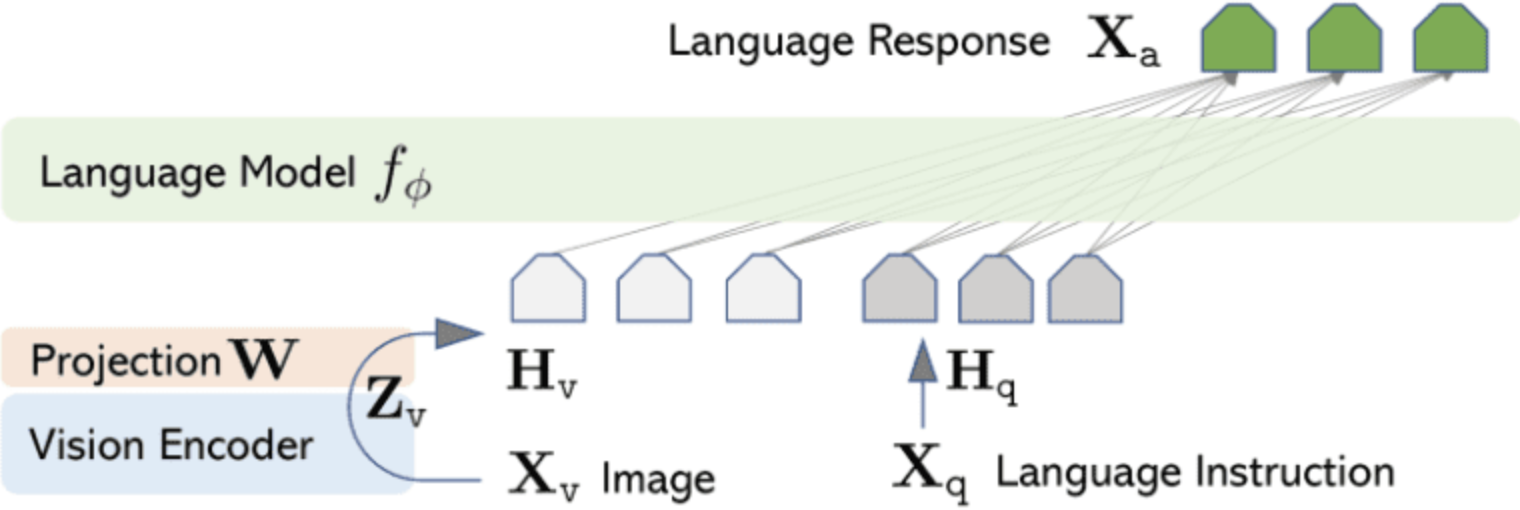


Instalamos lo necesario

In [ ]:
!pip install -q transformers accelerate torchvision torchaudio
!pip install -q git+https://github.com/huggingface/transformers.git
!pip install -q git+https://github.com/huggingface/peft.git

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


Importamos lo necesario

In [ ]:
import torch
from PIL import Image
import requests
from transformers import LlavaForConditionalGeneration, LlavaProcessor

Definimos el modelo y el procesador. Utilizaremos LLaVA 1.5 de 7B de HuggingFace.

In [ ]:
model_id = "llava-hf/llava-1.5-7b-hf"

processor = LlavaProcessor.from_pretrained(model_id)
model = LlavaForConditionalGeneration.from_pretrained(
    model_id,
    torch_dtype=torch.float16,
    low_cpu_mem_usage=True
)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


processor_config.json:   0%|          | 0.00/173 [00:00<?, ?B/s]

chat_template.json:   0%|          | 0.00/701 [00:00<?, ?B/s]

chat_template.jinja:   0%|          | 0.00/674 [00:00<?, ?B/s]

preprocessor_config.json:   0%|          | 0.00/505 [00:00<?, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/552 [00:00<?, ?B/s]

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 3 files:   0%|          | 0/3 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/686 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/141 [00:00<?, ?B/s]

Pasamos el modelo a CUDA

In [ ]:
model.to('cuda')

LlavaForConditionalGeneration(
  (model): LlavaModel(
    (vision_tower): CLIPVisionModel(
      (vision_model): CLIPVisionTransformer(
        (embeddings): CLIPVisionEmbeddings(
          (patch_embedding): Conv2d(3, 1024, kernel_size=(14, 14), stride=(14, 14), bias=False)
          (position_embedding): Embedding(577, 1024)
        )
        (pre_layrnorm): LayerNorm((1024,), eps=1e-05, elementwise_affine=True)
        (encoder): CLIPEncoder(
          (layers): ModuleList(
            (0-23): 24 x CLIPEncoderLayer(
              (self_attn): CLIPAttention(
                (k_proj): Linear(in_features=1024, out_features=1024, bias=True)
                (v_proj): Linear(in_features=1024, out_features=1024, bias=True)
                (q_proj): Linear(in_features=1024, out_features=1024, bias=True)
                (out_proj): Linear(in_features=1024, out_features=1024, bias=True)
              )
              (layer_norm1): LayerNorm((1024,), eps=1e-05, elementwise_affine=True)
       

Utiliza una imagen de tu preferencia. Debe ser una imagen que tiene extensión "JPG" al final. Ejemplo: "https://blabla.jpg"

In [ ]:
url = "https://raw.githubusercontent.com/haotian-liu/LLaVA/main/images/llava_logo.png" # URL de imagen válida
response = requests.get(url, stream=True)
if response.status_code == 200:
    image = Image.open(response.raw)
else:
    print("Error al descargar la imagen. Status code:", response.status_code)

Realizamos una pregunta con placeholders

In [ ]:
question = "USER: <image>\n¿Qué es esto?\nASSISTANT:"

Procesamos

In [ ]:
inputs = processor(images=image, text=question, return_tensors="pt").to('cuda')
output = model.generate(**inputs, max_new_tokens=50)

Decodificamos

In [ ]:
print(processor.decode(output[0], skip_special_tokens=True))

USER:  
¿Qué es esto?
ASSISTANT: Este es un modelo de un animal, probablemente un camello, hecho de plástico y con un diseño de llamas encendidas. El modelo está diseñado para parecerse a un animal con llamas encendidas


Realizamos dos diferentes preguntas utilizando dos diferentes imágenes. Una pregunta en español y otra en inglés.

Imagen 1 (español)

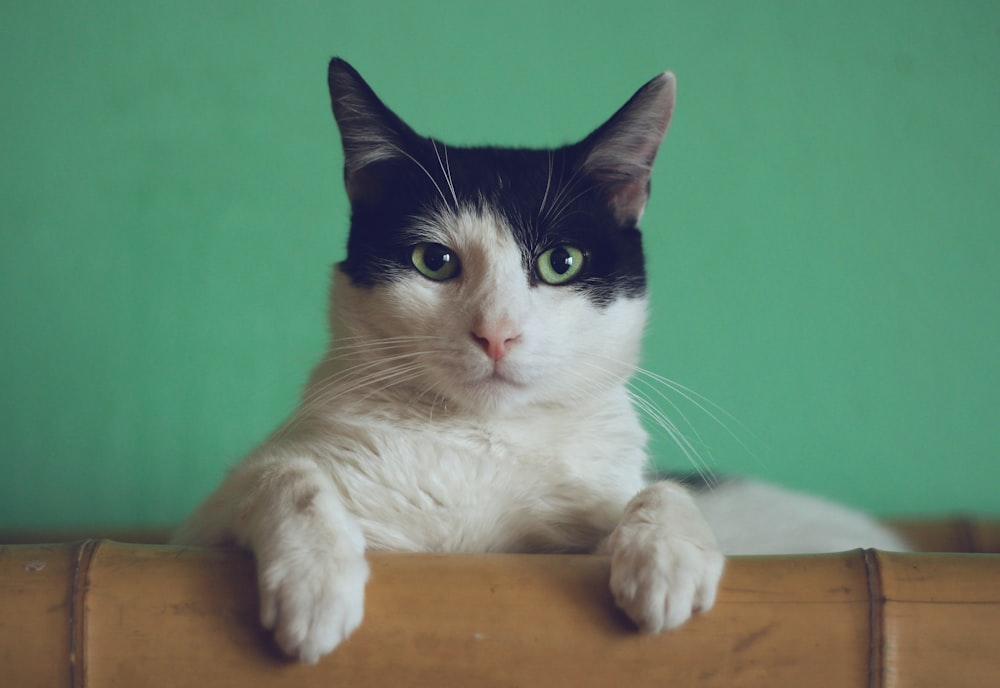

Respuesta 1:
USER:  
¿Qué animal aparece en la imagen?
ASSISTANT: En la imagen aparece un gato.


In [ ]:
url1 = "https://images.unsplash.com/photo-1514888286974-6c03e2ca1dba?q=80&w=1000&auto=format&fit=crop"
image1 = Image.open(requests.get(url1, stream=True).raw)
display(image1)

question1 = "USER: <image>\n¿Qué animal aparece en la imagen?\nASSISTANT:"

inputs1 = processor(images=image1, text=question1, return_tensors="pt").to("cuda")
output1 = model.generate(**inputs1, max_new_tokens=50)

print("Respuesta 1:")
print(processor.decode(output1[0], skip_special_tokens=True))

Imagen 2 (ingles)

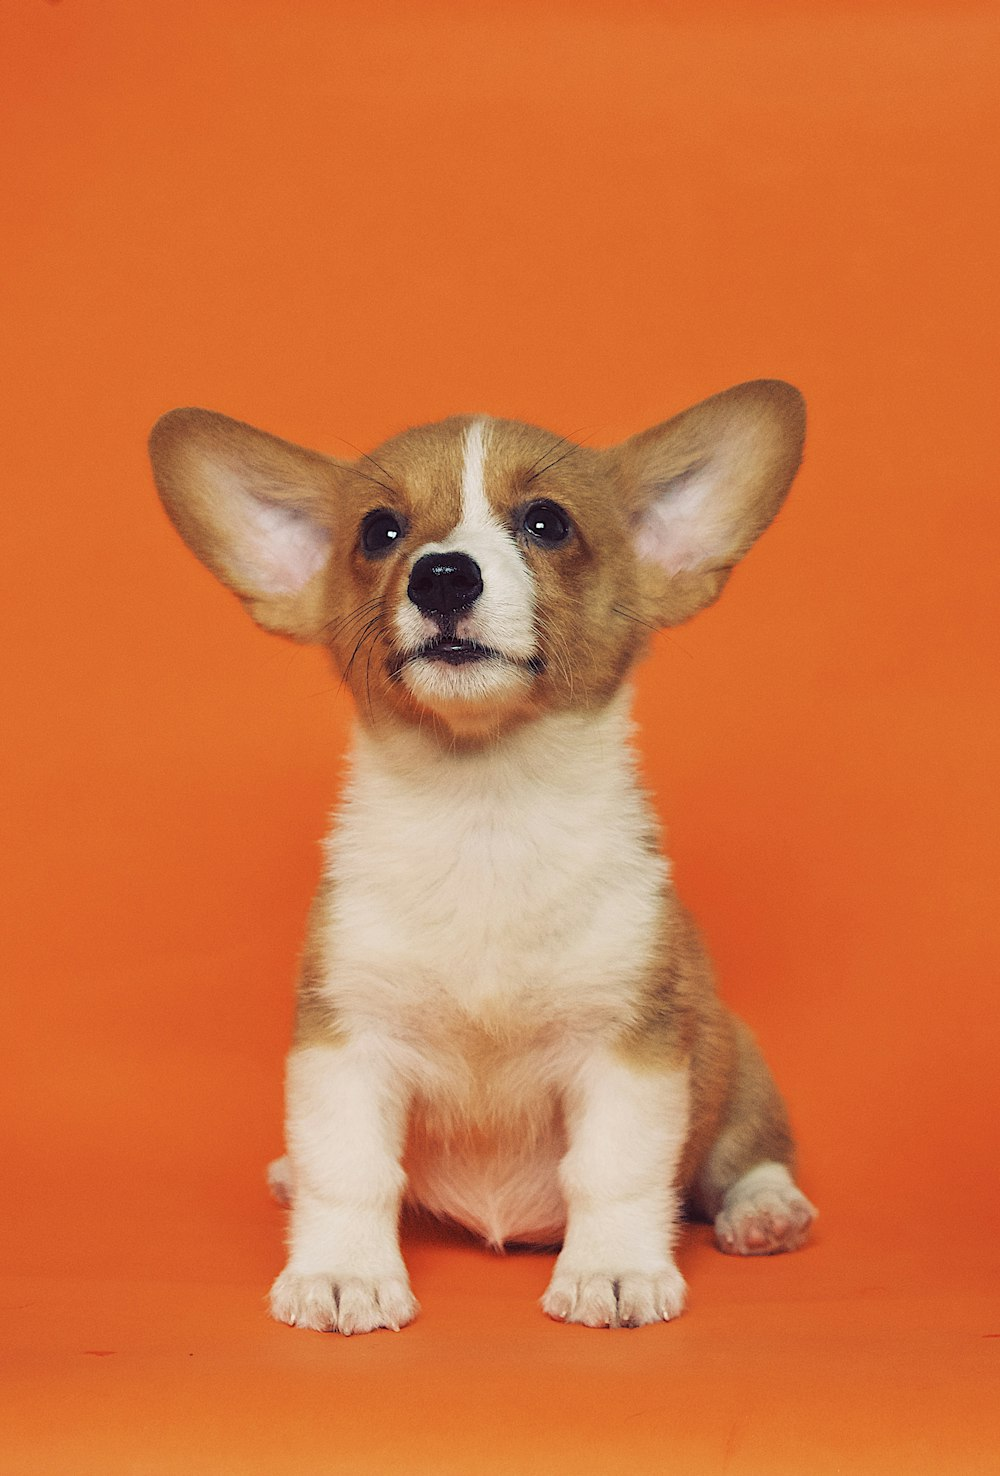


Respuesta 2:
USER:  
What animal is this?
ASSISTANT: This is a dog.


In [ ]:
url2 = "https://images.unsplash.com/photo-1537151608828-ea2b11777ee8?q=80&w=1000&auto=format&fit=crop"
image2 = Image.open(requests.get(url2, stream=True).raw)
display(image2)

question2 = "USER: <image>\nWhat animal is this?\nASSISTANT:"

inputs2 = processor(images=image2, text=question2, return_tensors="pt").to("cuda")
output2 = model.generate(**inputs2, max_new_tokens=50)

print("\nRespuesta 2:")
print(processor.decode(output2[0], skip_special_tokens=True))

Realizamos una pregunta más elaborada, realizando dos preguntas en un mismo prompt.

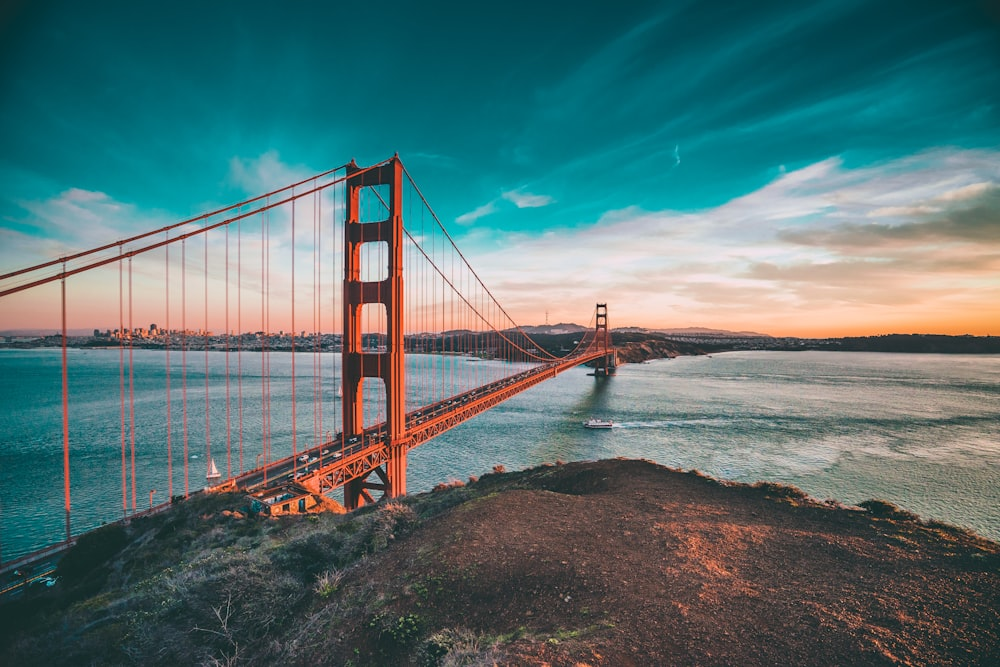

Respuesta Ejercicio 2 (Puente):
USER:  
¿Qué estructura principal ves aquí y qué elementos de ingeniería o transporte puedes identificar?
ASSISTANT: En la imagen, la estructura principal es el puente Golden Gate, que se extiende sobre el agua. Puedes identificar elementos de ingeniería y transporte como el puente, que es una estructura de ingeniería que permite el paso de vehículos y personas, así como la conexión entre dos partes de la ciudad. También pu


In [ ]:
url_multi = "https://images.unsplash.com/photo-1449034446853-66c86144b0ad?q=80&w=1000&auto=format&fit=crop"
image_multi = Image.open(requests.get(url_multi, stream=True).raw)
display(image_multi)

question_multi = "USER: <image>\n¿Qué estructura principal ves aquí y qué elementos de ingeniería o transporte puedes identificar?\nASSISTANT:"

inputs_multi = processor(images=image_multi, text=question_multi, return_tensors="pt").to("cuda")
output_multi = model.generate(**inputs_multi, max_new_tokens=80)

print("Respuesta Ejercicio 2 (Puente):")
print(processor.decode(output_multi[0], skip_special_tokens=True))

Realizamos una pregunta que se aplicará para dos imágenes. El proceso es similar pero el detalle está en como enviamos las imágenes en el procesador.

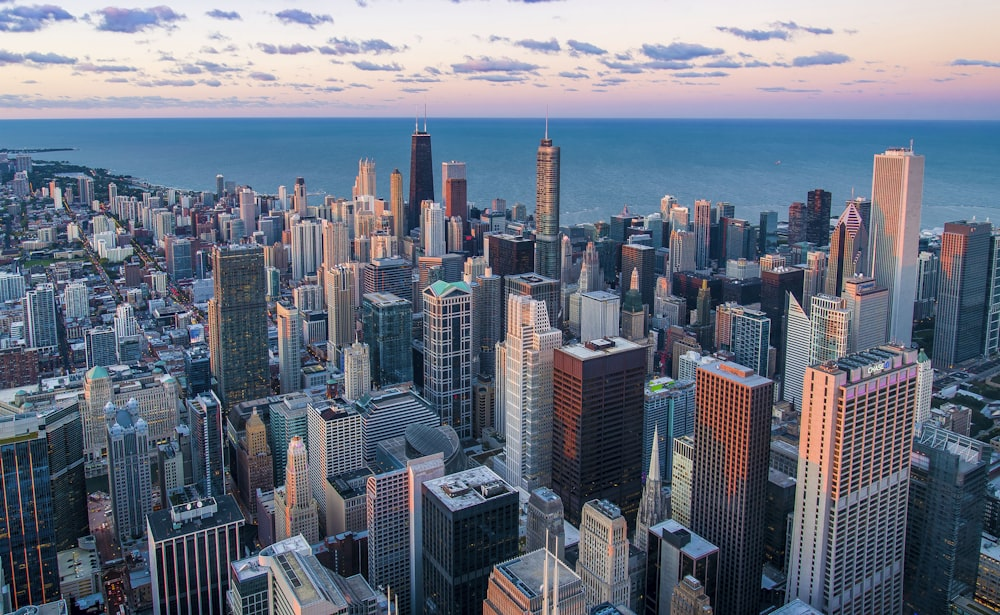

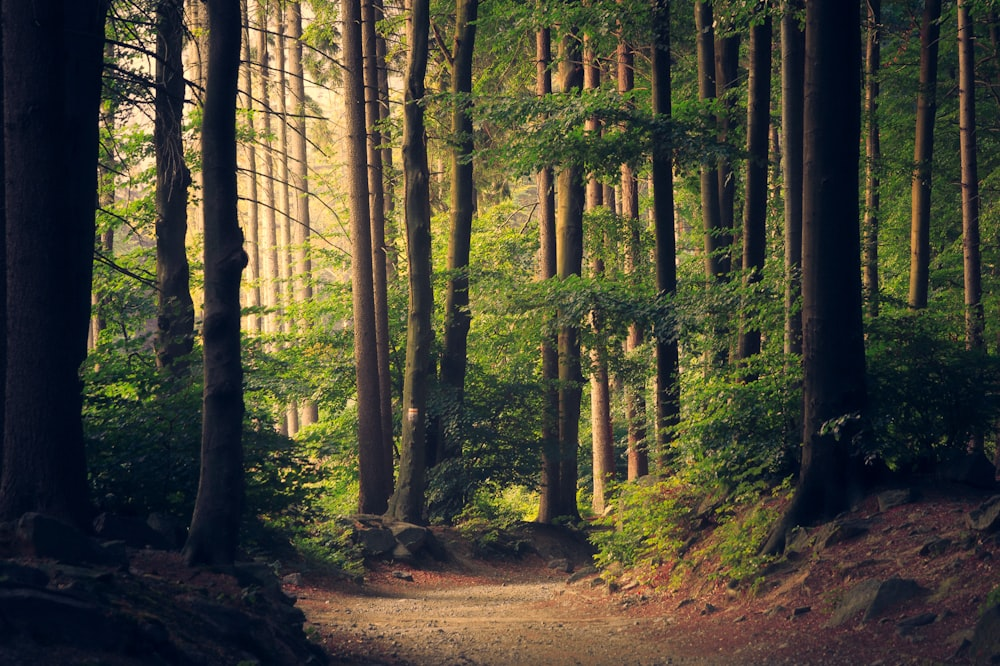

Respuesta Ejercicio 3 (Ciudad vs Bosque):

Respuesta imagen 1:
USER:  
Describe brevemente el paisaje predominante en esta imagen.
ASSISTANT: La imagen muestra una vista panorámica de una ciudad, con una gran cantidad de edificios y una vista del puerto. La ciudad se extiende hacia el horizonte, y la presencia de edificios alt

Respuesta imagen 2:
USER:  
Describe brevemente el paisaje predominante en esta imagen.
ASSISTANT: La imagen muestra un paisaje predominante de un sendero rodeado de árboles y vegetación. El sendero se encuentra en medio de un bosque, rodeado de árboles de diferentes tamaños


In [ ]:
url_city = "https://images.unsplash.com/photo-1477959858617-67f85cf4f1df?q=80&w=1000&auto=format&fit=crop"
url_nature = "https://images.unsplash.com/photo-1441974231531-c6227db76b6e?q=80&w=1000&auto=format&fit=crop"

image_city = Image.open(requests.get(url_city, stream=True).raw)
image_nature = Image.open(requests.get(url_nature, stream=True).raw)

display(image_city)
display(image_nature)

images = [image_city, image_nature]

question_batch = "USER: <image>\nDescribe brevemente el paisaje predominante en esta imagen.\nASSISTANT:"

inputs_batch = processor(
    images=images,
    text=[question_batch, question_batch],
    return_tensors="pt",
    padding=True
).to("cuda")

outputs_batch = model.generate(**inputs_batch, max_new_tokens=50)

print("Respuesta Ejercicio 3 (Ciudad vs Bosque):")
for i, out in enumerate(outputs_batch):
    print(f"\nRespuesta imagen {i+1}:")
    print(processor.decode(out, skip_special_tokens=True))